In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
shap_importance = pd.read_csv("../outputs/shap_importance.csv")
df_shap = pd.read_csv("../outputs/shap_ordering_results.csv")

df_rand = pd.read_csv("../outputs/feature_sets.csv")

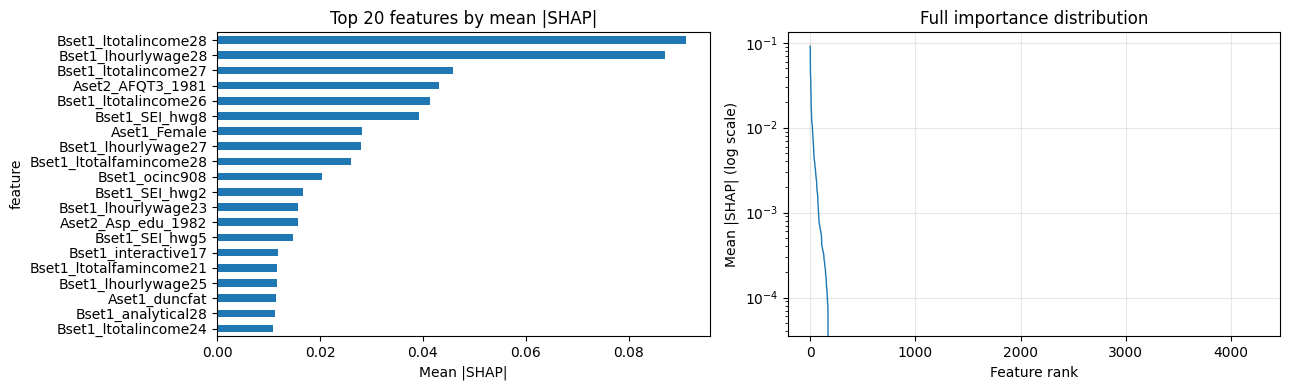

In [6]:
imp = shap_importance.set_index("feature")["mean_abs_shap"].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

imp.head(20).sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 20 features by mean |SHAP|")
axes[0].set_xlabel("Mean |SHAP|")

axes[1].plot(np.arange(1, len(imp) + 1), imp.to_numpy(), linewidth=1)
axes[1].set_yscale("log")
axes[1].set_xlabel("Feature rank")
axes[1].set_ylabel("Mean |SHAP| (log scale)")
axes[1].set_title("Full importance distribution")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
k_max = df_shap["k"].max()

full_metrics = (
    df_shap[df_shap["k"] == k_max]
    .groupby("direction")[["mse", "r2"]]
    .first()
)

full_metrics = (
    df_shap[df_shap["k"] == df_shap["k"].max()]
    .iloc[[0]][["mse", "r2"]]
)

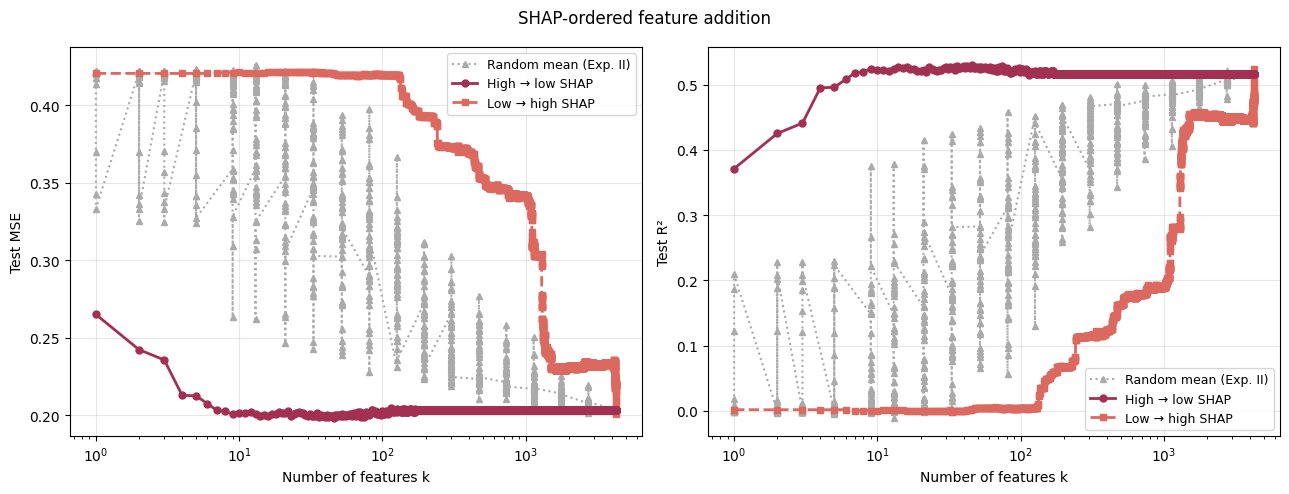

In [12]:
df_htl = df_shap[df_shap["direction"] == "high_to_low"].sort_values("k")
df_lth = df_shap[df_shap["direction"] == "low_to_high"].sort_values("k")

colors = {
    "high_to_low": "#A23052",
    "low_to_high": "#DC695F",
    "random": "#AAAAAA",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, ylabel in zip(axes, ["mse", "r2"], ["Test MSE", "Test R²"]):
    if df_rand is not None:
        rand_col = f"mean_{metric}" if f"mean_{metric}" in df_rand.columns else metric
        if rand_col in df_rand.columns:
            ax.plot(
                df_rand["k"], df_rand[rand_col],
                color=colors["random"], linewidth=1.5, linestyle=":", marker="^", markersize=4,
                label="Random mean (Exp. II)", zorder=1
            )

    ax.plot(df_htl["k"], df_htl[metric],
            color=colors["high_to_low"], linewidth=2,
            marker="o", markersize=5,
            label="High → low SHAP", zorder=3)

    ax.plot(df_lth["k"], df_lth[metric],
            color=colors["low_to_high"], linewidth=2,
            linestyle="--", marker="s", markersize=5,
            label="Low → high SHAP", zorder=2)

    ax.set_xscale("log")
    ax.set_xlabel("Number of features k")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle("SHAP-ordered feature addition")
plt.tight_layout()
plt.show()

## 5. Plot results

Compare the two SHAP curves against the random subsampling baseline.
Load the random results from the previous experiment if available.

In [3]:
# Load random subsampling baseline if it exists
random_path = "../outputs/feature_sets.csv"
df_rand = pd.read_csv(random_path) if os.path.exists(random_path) else None
if df_rand is not None:
    print(f"Loaded random baseline: {random_path}")
    print(df_rand.columns.tolist())
else:
    print("No random baseline found — plotting SHAP curves only.")

Loaded random baseline: ../outputs/feature_sets.csv
['k', 'seed', 'mse', 'r2']


## 6. (Optional) Fit asymptote to high-to-low curve

Fit a shifted power law to the high-to-low curve to extract ε∞,
and compare with the bounds from the other two experiments:

| Experiment | Method | ε∞ |
|---|---|---|
| I | Sample size scaling | 0.029 |
| II | Random features | 0.193 |
| III | SHAP high-to-low | TBD (below) |

In [15]:
from scipy.optimize import curve_fit

def shifted_power_law(k, C, alpha, d, eps):
    return C * (k + d) ** (-alpha) + eps

def power_law(k, C, alpha, eps):
    return C * k ** (-alpha) + eps

k_arr  = df_htl["k"].values.astype(float)
mse_arr = df_htl["mse"].values

# Weights: emphasise large-k points (same as Exp. II)
weights = 1.0 / np.sqrt(k_arr)

try:
    popt_spl, _ = curve_fit(
        shifted_power_law, k_arr, mse_arr,
        p0=[2.0, 0.5, 10.0, 0.15],
        bounds=([0, 0, 0, 0], [100, 5, 1000, 1]),
        sigma=weights, maxfev=10000
    )
    C_spl, alpha_spl, d_spl, eps_spl = popt_spl
    print("Shifted power law fit (high-to-low):")
    print(f"  MSE(k) = {C_spl:.3f} * (k + {d_spl:.1f})^(-{alpha_spl:.3f}) + {eps_spl:.4f}")
    print(f"  Asymptote ε∞ = {eps_spl:.4f}  ← Bound III")
except RuntimeError as e:
    print(f"Shifted power law fit failed: {e}")
    popt_spl = None

try:
    popt_pl, _ = curve_fit(
        power_law, k_arr, mse_arr,
        p0=[0.4, 0.25, 0.15],
        bounds=([0, 0, 0], [10, 5, 1]),
        sigma=weights, maxfev=10000
    )
    C_pl, alpha_pl, eps_pl = popt_pl
    print(f"\nPower law fit:  MSE(k) = {C_pl:.3f} * k^(-{alpha_pl:.3f}) + {eps_pl:.4f}")
except RuntimeError as e:
    print(f"Power law fit failed: {e}")
    popt_pl = None

Shifted power law fit (high-to-low):
  MSE(k) = 0.000 * (k + 70.0)^(-1.621) + 0.2036
  Asymptote ε∞ = 0.2036  ← Bound III

Power law fit:  MSE(k) = 0.075 * k^(-2.133) + 0.2036


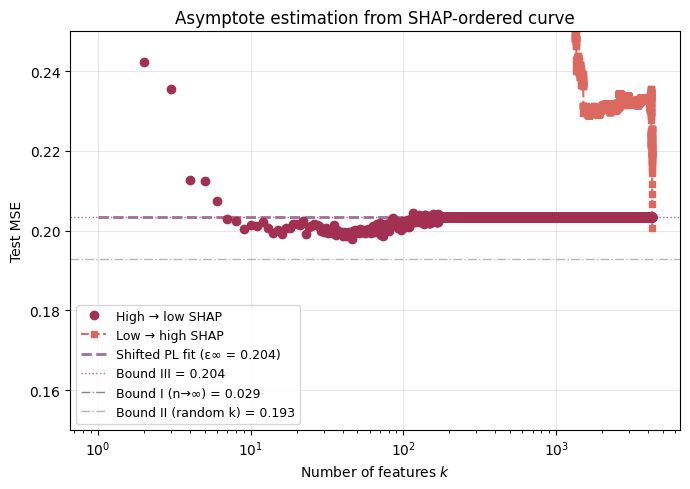

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))

df_htl = df_htl.sort_values("k")
df_lth = df_lth.sort_values("k")

ax.plot(df_htl["k"], df_htl["mse"],
        "o", color="#A23052", markersize=6, label="High → low SHAP", zorder=3)

ax.plot(df_lth["k"], df_lth["mse"],
        "s--", color="#DC695F", markersize=5, linewidth=1.5,
        label="Low → high SHAP", zorder=2)

k_max = max(df_htl["k"].max(), df_lth["k"].max())
k_fine = np.logspace(0, np.log10(k_max), 200)

if popt_spl is not None:
    ax.plot(k_fine, shifted_power_law(k_fine, *popt_spl),
            color="#A26E94", linewidth=2, linestyle="--",
            label=f"Shifted PL fit (ε∞ = {eps_spl:.3f})")
    ax.axhline(eps_spl, color="#A26E94", linewidth=1,
               linestyle=":", label=f"Bound III = {eps_spl:.3f}")

ax.axhline(0.029, color="#555", linewidth=1, linestyle="-.",
           alpha=0.7, label="Bound I (n→∞) = 0.029")
ax.axhline(0.193, color="#999", linewidth=1, linestyle="-.",
           alpha=0.7, label="Bound II (random k) = 0.193")

ax.set_xscale("log")
ax.set_ylim(0.15, 0.25)
ax.set_xlabel("Number of features $k$")
ax.set_ylabel("Test MSE")
ax.set_title("Asymptote estimation from SHAP-ordered curve")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/shap_bound.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
a, b, c, eps = popt_spl
print(f"a={a}")
print(f"b={b}")
print(f"c={c}")
print(f"eps={eps}")

a=1.10037523561024e-17
b=1.6208589368895356
c=70.0050177772419
eps=0.20355460577499096


In [18]:
# Summary table of all three bounds
bounds = pd.DataFrame([
    {"Experiment": "I",  "Method": "Sample size (n→∞, all features)",   "eps_inf": 0.029,       "Status": "Done"},
    {"Experiment": "II", "Method": "Random features (k→K, fixed n)",    "eps_inf": 0.193,       "Status": "Done"},
    {"Experiment": "III","Method": "SHAP high-to-low (k→K)",
     "eps_inf": round(eps_spl, 4) if popt_spl is not None else float("nan"),
     "Status": "Done" if popt_spl is not None else "Fit failed"},
])
print(bounds.to_string(index=False))

Experiment                          Method  eps_inf Status
         I Sample size (n→∞, all features)   0.0290   Done
        II  Random features (k→K, fixed n)   0.1930   Done
       III          SHAP high-to-low (k→K)   0.2036   Done
